In [1]:
# =========================
# GEREKLİ KÜTÜPHANELER
# =========================
import networkx as nx
import json
import random
import math
import numpy as np

# =========================
# JSON'DAN AĞ YÜKLEME
# =========================
class NetworkFromJSON:
    def __init__(self, json_file):
        self.json_file = json_file
        self.graph = nx.Graph()
        self.node_properties = {}
        self.link_properties = {}

    def load(self):
        with open(self.json_file, "r") as f:
            data = json.load(f)

        # Düğümler
        if "nodes" in data:
            self.graph.add_nodes_from([int(n) for n in data["nodes"]])
        else:
            self.graph.add_nodes_from(range(len(data["node_properties"])))

        # Kenarlar
        self.graph.add_edges_from([tuple(e) for e in data["edges"]])

        # Node özellikleri
        self.node_properties = {
            int(k): v for k, v in data["node_properties"].items()
        }

        # Link özellikleri
        self.link_properties = {
            eval(k): v for k, v in data["link_properties"].items()
        }

        print("✓ Ağ JSON'dan yüklendi")
        print(f"  Düğüm sayısı   : {self.graph.number_of_nodes()}")
        print(f"  Bağlantı sayısı: {self.graph.number_of_edges()}")

        return self.graph

# =========================
# COST (MALİYET) FONKSİYONU
# =========================
def compute_cost(path, network,
                 w_delay=0.4,
                 w_reliability=0.3,
                 w_resource=0.3):

    total_delay = 0.0
    total_reliability = 1.0
    resource_cost = 0.0

    # Kenar metrikleri
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        e = network.link_properties[(u, v)]

        total_delay += e["delay"]
        total_reliability *= e["reliability"]
        resource_cost += 1000 / e["bandwidth"]

    # Düğüm metrikleri
    for n in path:
        node = network.node_properties[n]
        total_delay += node["processing_delay"]
        total_reliability *= node["reliability"]

    reliability_cost = -math.log(total_reliability)

    total_cost = (
        w_delay * total_delay +
        w_reliability * reliability_cost +
        w_resource * resource_cost
    )

    return {
        "TotalCost": total_cost,
        "Delay": total_delay,
        "Reliability": total_reliability,
        "Resource": resource_cost
    }

# =========================
# ACO ALGORİTMASI
# =========================
def run_aco(network, G, S, D,
            num_ants=25,
            iterations=40,
            alpha=1,
            beta=2,
            evaporation=0.3):

    # Feromon başlangıcı
    pheromone = {}
    for u, v in G.edges():
        pheromone[(u, v)] = 1.0
        pheromone[(v, u)] = 1.0

    best_path = None
    best_cost = float("inf")
    best_iteration = -1

    def heuristic(u, v):
        e = network.link_properties[(u, v)]
        h = e["delay"] + (1000 / e["bandwidth"]) - math.log(e["reliability"])
        return 1 / h if h > 0 else 1

    for it in range(iterations):
        for _ in range(num_ants):
            current = S
            visited = {S}
            path = [S]

            while current != D:
                neighbors = [n for n in G.neighbors(current) if n not in visited]
                if not neighbors:
                    path = None
                    break

                probs = []
                total = 0
                for n in neighbors:
                    p = (pheromone[(current, n)] ** alpha) * (heuristic(current, n) ** beta)
                    probs.append(p)
                    total += p

                probs = [p / total for p in probs]
                next_node = random.choices(neighbors, probs)[0]

                path.append(next_node)
                visited.add(next_node)
                current = next_node

            if path is None:
                continue

            metrics = compute_cost(path, network)

            # EN İYİ SONUÇ ve ITERASYON TAKİBİ
            if metrics["TotalCost"] < best_cost:
                best_cost = metrics["TotalCost"]
                best_path = path
                best_iteration = it + 1

        # Feromon buharlaşma
        for k in pheromone:
            pheromone[k] *= (1 - evaporation)

        # Feromon güçlendirme
        if best_path:
            for i in range(len(best_path) - 1):
                u, v = best_path[i], best_path[i + 1]
                pheromone[(u, v)] += 1 / best_cost
                pheromone[(v, u)] += 1 / best_cost

        print(f"[ACO] Iter {it+1}/{iterations} → Best Cost: {best_cost:.4f}")

    return best_path, compute_cost(best_path, network), best_iteration

# =========================
# MAIN
# =========================
network = NetworkFromJSON("network_250_nodes.json")
G = network.load()

S = 20
D = 200

best_path, metrics, best_iter = run_aco(network, G, S, D)

print("\n=== ACO SONUÇ ===")
print("En iyi yol:", best_path)
print(f"En iyi sonuç {best_iter}. iterasyonda bulundu")

print("\nMetrikler ->")
print("-" * 60)
for k, v in metrics.items():
    print(f"{k}: {v}")
print("-" * 60)

print("\nBİLGİLENDİRME (GUI ve Diğer Algoritma Ekibi İçin)")
print("=" * 60)
print("• Kullanılan ağ dosyası      : network_250_nodes.json")
print("• Algoritma                 : Ant Colony Optimization (ACO)")
print("• Girişler                  : Kaynak düğüm (S), Hedef düğüm (D)")
print("• Ayarlanabilir parametreler:")
print("    - w_delay, w_reliability, w_resource (cost ağırlıkları)")
print("    - num_ants, iterations, alpha, beta, evaporation")
print("• Çıktılar                  :")
print("    - En iyi yol (node listesi)")
print("    - Toplam maliyet (TotalCost)")
print("    - Delay, Reliability, Resource metrikleri")
print("• GUI geliştiriciler, aynı ağ dosyasını kullanarak")
print("  bu algoritmayı arayüze entegre edebilir.")
print("=" * 60)


✓ Ağ JSON'dan yüklendi
  Düğüm sayısı   : 250
  Bağlantı sayısı: 12426
[ACO] Iter 1/40 → Best Cost: 155.9738
[ACO] Iter 2/40 → Best Cost: 73.7126
[ACO] Iter 3/40 → Best Cost: 16.8906
[ACO] Iter 4/40 → Best Cost: 16.8906
[ACO] Iter 5/40 → Best Cost: 11.8148
[ACO] Iter 6/40 → Best Cost: 11.8148
[ACO] Iter 7/40 → Best Cost: 10.0282
[ACO] Iter 8/40 → Best Cost: 10.0282
[ACO] Iter 9/40 → Best Cost: 10.0282
[ACO] Iter 10/40 → Best Cost: 10.0282
[ACO] Iter 11/40 → Best Cost: 9.4693
[ACO] Iter 12/40 → Best Cost: 9.4693
[ACO] Iter 13/40 → Best Cost: 9.4693
[ACO] Iter 14/40 → Best Cost: 9.4693
[ACO] Iter 15/40 → Best Cost: 9.4693
[ACO] Iter 16/40 → Best Cost: 9.4693
[ACO] Iter 17/40 → Best Cost: 9.4693
[ACO] Iter 18/40 → Best Cost: 9.4693
[ACO] Iter 19/40 → Best Cost: 9.4693
[ACO] Iter 20/40 → Best Cost: 9.4693
[ACO] Iter 21/40 → Best Cost: 9.4693
[ACO] Iter 22/40 → Best Cost: 9.4693
[ACO] Iter 23/40 → Best Cost: 9.4693
[ACO] Iter 24/40 → Best Cost: 9.4693
[ACO] Iter 25/40 → Best Cost: 9.4693
[A

Görselleştirilen Yol Uzunluğu: 4 düğüm


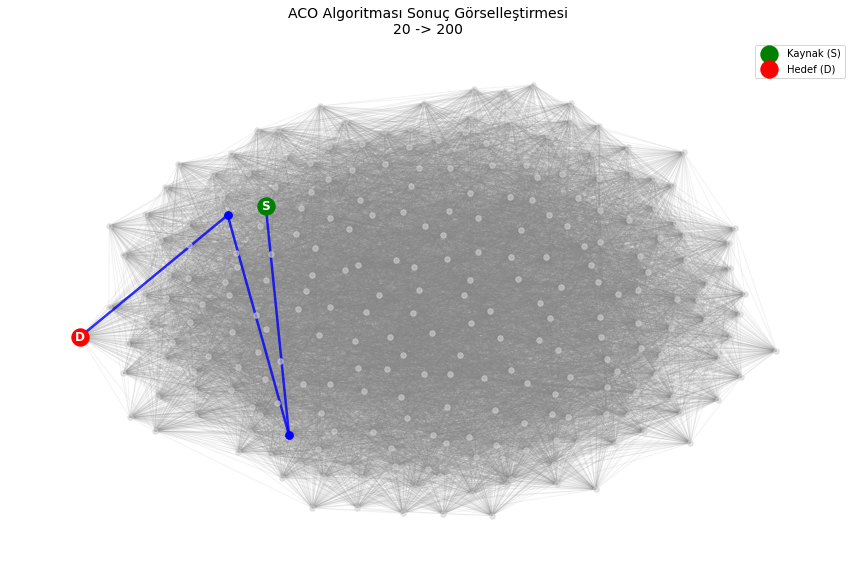

In [2]:
import matplotlib.pyplot as plt

def visualize_aco_result(G, path, S, D):
    """
    Ağı ve ACO tarafından bulunan en iyi yolu görselleştirir.
    S: Kaynak (Yeşil)
    D: Hedef (Kırmızı)
    Yol: Kalın Mavi Çizgi
    """
    plt.figure(figsize=(12, 8)) # Resim boyutu
    
    # 1. Düğüm Pozisyonlarını Belirle (Sabit dursun diye seed veriyoruz)
    pos = nx.spring_layout(G, seed=42, k=0.15) 
    
    # 2. Tüm Ağı Çiz (Arkaplan - Silik Gri)
    # Düğümler
    nx.draw_networkx_nodes(G, pos, node_size=30, node_color='lightgray', alpha=0.6)
    # Kenarlar
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')
    
    # 3. Bulunan Yolu Çiz (Vurgulu)
    if path:
        # Yol üzerindeki kenarları bul
        path_edges = list(zip(path, path[1:]))
        
        # Yolu çiz
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_size=60, node_color='blue')
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=2.5, edge_color='blue', alpha=0.8)
        
        print(f"Görselleştirilen Yol Uzunluğu: {len(path)} düğüm")

    # 4. Kaynak (S) ve Hedef (D) Düğümlerini Özel İşaretle
    # Kaynak (S) -> YEŞİL BÜYÜK
    nx.draw_networkx_nodes(G, pos, nodelist=[S], node_size=300, node_color='green', label="Kaynak (S)")
    nx.draw_networkx_labels(G, pos, labels={S: "S"}, font_color="white", font_weight="bold")
    
    # Hedef (D) -> KIRMIZI BÜYÜK
    nx.draw_networkx_nodes(G, pos, nodelist=[D], node_size=300, node_color='red', label="Hedef (D)")
    nx.draw_networkx_labels(G, pos, labels={D: "D"}, font_color="white", font_weight="bold")

    plt.title(f"ACO Algoritması Sonuç Görselleştirmesi\n{S} -> {D}", fontsize=14)
    plt.axis('off') # Eksenleri kapat
    plt.legend(loc='upper right') # Lejant ekle
    plt.tight_layout()
    plt.show()

# ==============================
# ÇALIŞTIRMA KISMI
# ==============================
# Yukarıdaki ACO kodu çalışıp 'best_path' değişkenini ürettikten sonra burası çalışır.
if best_path:
    visualize_aco_result(G, best_path, S, D)
else:
    print("Görselleştirilecek bir yol bulunamadı!")